In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import pandas as pd
sys.path.append('/Users/wayne/Desktop/Cluster/ClusterHome/gitrepo/2024/OncoTRAIL/src')
sys.path.append('/Users/wayne/Desktop/Cluster/ClusterHome/gitrepo/2024/OncoTRAIL/src/prompt')
from constants import target_dict_mapping
from utils import target_category
import matplotlib as mpl

mpl.rcParams["svg.fonttype"] = "none"   # Keep text as text (not paths)
mpl.rcParams["pdf.fonttype"] = 42       # Editable text in PDF
mpl.rcParams["ps.fonttype"] = 42

colors = ['#a1d4cc', '#eee5bb', '#d4a1cc' , '#c4e5f6']
methods = ["tabular", "prompting", "bag of words", "finetune"]
# create a dictionary mapping method to color
color_map = {method: colors[i % len(colors)] for i, method in enumerate(methods)}

def concordance_correlation_coefficient(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    mean_x = np.mean(x)
    mean_y = np.mean(y)

    var_x = np.var(x, ddof=1)
    var_y = np.var(y, ddof=1)

    cov_xy = np.cov(x, y, ddof=1)[0, 1]

    ccc = (2 * cov_xy) / (var_x + var_y + (mean_x - mean_y) ** 2)
    return ccc

def plot_split_concordance(tidy_df, point_estimate_df, method_colors, x_split='test', y_split='inference',
                          figsize=(20, 5), figsize_mm=None):
    """
    Plot concordance between two data splits across bootstrap iterations with confidence ribbons.
    
    Parameters:
    -----------
    tidy_df : pd.DataFrame
        DataFrame with columns: method, split, boot_id, auc, target
    point_estimate_df : pd.DataFrame
        DataFrame with columns: method, split, auc, target
    method_colors : dict
        Dictionary mapping method names to colors
    x_split : str
        Name of split to use for x-axis (default: 'test')
    y_split : str
        Name of split to use for y-axis (default: 'inference')
    figsize : tuple
        Figure size (width, height) in inches
    figsize_mm : tuple, optional
        Figure size as (width_mm, height_mm). Overrides figsize if provided.
    
    Returns:
    --------
    Tuple[plt.Figure, np.ndarray]
        Figure and array of axes objects
    """

    # Font size controls
    fontsize_axes = 4       # x/y axis labels, tick labels, panel title
    fontsize_legend = 4     # legend text
    
    # Target type colors
    target_type_colors = {
        'clinic': '#88bb99',
        'lab': '#e6b3bb',
        'symptom': '#9a91c4',
    }
    
    # Specify method ordering
    method_order = ['tabular', 'bag of words', 'finetune', 'prompting']
    available_methods = tidy_df['method'].unique()
    methods = [m for m in method_order if m in available_methods] + \
              [m for m in sorted(available_methods) if m not in method_order]
    targets = sorted(tidy_df['target'].unique())

    # Convert mm to inches if figsize_mm is provided
    if figsize_mm is not None:
        figsize = (figsize_mm[0] / 25.4, figsize_mm[1] / 25.4)
    
    # Create 1x4 subplot
    fig, axes = plt.subplots(1, 4, figsize=figsize, sharex=True, sharey=True)
    
    # Determine global axis limits
    all_aucs = tidy_df['auc'].values
    auc_min = max(0.4, np.floor(all_aucs.min() * 10) / 10)
    auc_max = min(1.0, np.ceil(all_aucs.max() * 10) / 10)
    
    for ax_idx, method in enumerate(methods):
        ax = axes[ax_idx]
        
        # Filter data for this method
        method_df = tidy_df[tidy_df['method'] == method].copy()
        
        # Storage for bootstrap results
        all_slopes = []
        all_intercepts = []
        all_cccs = []
        
        # Loop over each bootstrap iteration
        for boot_id in range(1000):
            boot_df = method_df[method_df['boot_id'] == boot_id]
            
            # Get x and y values for this bootstrap iteration
            x_vals = []
            y_vals = []
            
            for target in targets:
                x_val = boot_df[(boot_df['split'] == x_split) & 
                               (boot_df['target'] == target)]['auc'].values
                y_val = boot_df[(boot_df['split'] == y_split) & 
                               (boot_df['target'] == target)]['auc'].values
                
                if len(x_val) > 0 and len(y_val) > 0:
                    x_vals.append(x_val[0])
                    y_vals.append(y_val[0])
            
            x_vals = np.array(x_vals)
            y_vals = np.array(y_vals)
            
            # Compute CCC
            ccc = concordance_correlation_coefficient(x_vals, y_vals)
            
            # Fit line: y = slope * x + intercept
            slope, intercept = np.polyfit(x_vals, y_vals, 1)
            
            # Skip this bootstrap sample if any result is nan
            if np.isnan(ccc) or np.isnan(slope) or np.isnan(intercept):
                continue
            
            all_cccs.append(ccc)
            all_slopes.append(slope)
            all_intercepts.append(intercept)

        # Convert to arrays
        all_slopes = np.array(all_slopes)
        all_intercepts = np.array(all_intercepts)
        all_cccs = np.array(all_cccs)
        
        # Create x values for ribbon plotting
        x_ribbon = np.linspace(auc_min, auc_max, 100)
        
        # Calculate y values for each bootstrap line
        y_ribbon_lines = []
        for slope, intercept in zip(all_slopes, all_intercepts):
            y_ribbon_lines.append(slope * x_ribbon + intercept)
        y_ribbon_lines = np.array(y_ribbon_lines)
        
        # Calculate percentiles for ribbon
        y_ribbon_lower = np.percentile(y_ribbon_lines, 2.5, axis=0)
        y_ribbon_upper = np.percentile(y_ribbon_lines, 97.5, axis=0)
        
        # Plot the ribbon
        ax.fill_between(x_ribbon, y_ribbon_lower, y_ribbon_upper,
                        color=method_colors[method], alpha=0.3, 
                        label='95% CI', zorder=1)
        
        # Calculate point estimate of aucs for scatter plot
        # Store by target type for coloring
        pt_estimate_data_by_type = {'clinic': {'x': [], 'y': []}, 
                            'lab': {'x': [], 'y': []}, 
                            'symptom': {'x': [], 'y': []}}
        
        pt_method_df = point_estimate_df[point_estimate_df['method'] == method]
        for target in targets:
            x_target = pt_method_df[(pt_method_df['split'] == x_split) &
                                    (pt_method_df['target'] == target)]['auc'].values
            y_target = pt_method_df[(pt_method_df['split'] == y_split) &
                                    (pt_method_df['target'] == target)]['auc'].values

            if len(x_target) > 0 and len(y_target) > 0:
                target_type = target_category(target)
                pt_estimate_data_by_type[target_type]['x'].append(x_target[0])
                pt_estimate_data_by_type[target_type]['y'].append(y_target[0])
        
        # Combine all mean values for line fitting
        all_pt_estimate_x = []
        all_pt_estimate_y = []
        for target_type in ['clinic', 'lab', 'symptom']:
            all_pt_estimate_x.extend(pt_estimate_data_by_type[target_type]['x'])
            all_pt_estimate_y.extend(pt_estimate_data_by_type[target_type]['y'])
        
        all_pt_estimate_x = np.array(all_pt_estimate_x)
        all_pt_estimate_y = np.array(all_pt_estimate_y)
        
        # Fit line through mean points
        pt_estimate_slope, pt_estimate_intercept = np.polyfit(all_pt_estimate_x, all_pt_estimate_y, 1)
        y_pt_estimate_line = pt_estimate_slope * x_ribbon + pt_estimate_intercept
        
        # Plot mean line
        ax.plot(x_ribbon, y_pt_estimate_line, color=method_colors[method], 
                linewidth=2, label='Fitted line', zorder=3)
        
        # Plot scatter points colored by target type
        for target_type in ['clinic', 'lab', 'symptom']:
            x_vals = pt_estimate_data_by_type[target_type]['x']
            y_vals = pt_estimate_data_by_type[target_type]['y']
            
            if len(x_vals) > 0:
                ax.scatter(x_vals, y_vals, color=target_type_colors[target_type], 
                          s=15, alpha=0.7, edgecolors='black', linewidth=0.5, 
                          zorder=4, label=target_type.capitalize() if ax_idx == 0 else None)
        
        # Plot y=x diagonal line (gray, dashed, linewidth=0.8 — consistent with other plots)
        ax.plot([auc_min, auc_max], [auc_min, auc_max],
                color='gray', linestyle='dashed', linewidth=0.8,
                zorder=2, label='y=x')
        
        # Calculate CCC statistics
        pt_x = pt_method_df[pt_method_df['split'] == x_split].set_index('target')['auc']
        pt_y = pt_method_df[pt_method_df['split'] == y_split].set_index('target')['auc']
        shared_targets = pt_x.index.intersection(pt_y.index)
        ccc_pt_estimate = concordance_correlation_coefficient(
            pt_x.loc[shared_targets].values,
            pt_y.loc[shared_targets].values
        )

        ccc_lower = np.percentile(all_cccs, 2.5)
        ccc_upper = np.percentile(all_cccs, 97.5)

        # Compute mean delta (mean of y - x across all scatter points)
        all_deltas = []
        for target_type in ['clinic', 'lab', 'symptom']:
            xs = pt_estimate_data_by_type[target_type]['x']
            ys = pt_estimate_data_by_type[target_type]['y']
            for x_val, y_val in zip(xs, ys):
                all_deltas.append(y_val - x_val)
        mean_delta = np.mean(all_deltas) if all_deltas else float('nan')
        
        ax.text(
            0.03, 0.97,
            f'CCC {ccc_pt_estimate:.2f} [{ccc_lower:.2f}, {ccc_upper:.2f}]\nΔ {mean_delta:+.2f}',
            transform=ax.transAxes,
            fontsize=fontsize_legend,
            va='top',
            ha='left'
        )

        # Set axis limits
        ax.set_xlim(auc_min, auc_max)
        ax.set_ylim(auc_min, auc_max)
        
        # rename x_split and y_split for labels
        if x_split == 'test':
            x_split_label = '(2016-2019)'
        elif x_split == 'inference':
            x_split_label = '(2022-2024)'
        elif x_split == 'inference_aero':
            x_split_label = 'aerodigestive'
        elif x_split == 'inference_other':
            x_split_label = 'other'

        if y_split == 'test':
            y_split_label = '(2016-2019)'
        elif y_split == 'inference':
            y_split_label = '(2022-2024)'
        elif y_split == 'inference_aero':
            y_split_label = 'aerodigestive'
        elif y_split == 'inference_other':
            y_split_label = 'other'

        # Labels and title — no bold, uniform fontsize_axes
        if ax_idx == 0:
            ax.set_ylabel(f'AUC {y_split_label}', fontsize=fontsize_axes)
        ax.set_xlabel(f'AUC {x_split_label}', fontsize=fontsize_axes)
        ax.set_title(f'{method}', fontsize=fontsize_axes)   # no fontweight='bold'
        ax.tick_params(axis='both', labelsize=fontsize_axes)

        # Remove grid lines
        ax.grid(False)

        # Only left (y-axis) and bottom (x-axis) spines, uniform linewidth
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(1.0)
        ax.spines['bottom'].set_linewidth(1.0)
        
        from matplotlib.patches import Patch
        from matplotlib.lines import Line2D

        # Compact legend (only for first subplot)
        if ax_idx == 0:
            legend_elements = [
                Patch(facecolor='gray', alpha=0.3, label='95% CI'),
                Line2D([0], [0], color='gray', linewidth=2, label='Fit'),
                Line2D([0], [0], color='gray', linestyle='dashed', linewidth=0.8, label='y=x'),
                Line2D([0], [0], marker='o', color='w',
                    markerfacecolor=target_type_colors['clinic'],
                    markersize=2, markeredgecolor='black',
                    markeredgewidth=0.5, label='Clinic'),
                Line2D([0], [0], marker='o', color='w',
                    markerfacecolor=target_type_colors['lab'],
                    markersize=2, markeredgecolor='black',
                    markeredgewidth=0.5, label='Lab'),
                Line2D([0], [0], marker='o', color='w',
                    markerfacecolor=target_type_colors['symptom'],
                    markersize=2, markeredgecolor='black',
                    markeredgewidth=0.5, label='Symptom'),
            ]

            ax.legend(
                handles=legend_elements,
                loc='lower right',
                fontsize=fontsize_legend,
                framealpha=0.95,
                edgecolor='gray',
                fancybox=True,
                handlelength=0.8,
                handletextpad=0.3,
                borderpad=0.3,
                labelspacing=0.2,
                ncol=2,              # <-- key for compression
                columnspacing=0.8
            )
    
    plt.tight_layout()
    
    return fig, axes


# Example usage:
# fig, axes = plot_split_concordance(
#     tidy_df, 
#     method_colors={'method1': '#0072B2', 'method2': '#E69F00', 
#                    'method3': '#009E73', 'method4': '#CC79A7'},
#     x_split='test',
#     y_split='inference'
# )
# plt.show()

In [2]:
tidy_df = pd.read_csv('/Users/wayne/Desktop/Cluster/WorkDirHome/gitrepo/2024/OncoTRAIL/paper/pmh_method/results/aggregate/aggregate_bootstrap_results.csv')
tidy_df['target'] = tidy_df['target'].astype(str).str.replace('_','-')
# rename method value of 'nlp-tfidf' to 'bag of words'
tidy_df['method'] = tidy_df['method'].replace({'nlp-tfidf': 'bag of words'})
tidy_df = tidy_df.loc[tidy_df['method'] != 'nlp-count'].copy()
point_estimate_df = pd.read_csv('/Users/wayne/Desktop/Cluster/WorkDirHome/gitrepo/2024/OncoTRAIL/paper/pmh_method/results/aggregate/aggregate_point_estimate_results.csv')
point_estimate_df['target'] = point_estimate_df['target'].astype(str).str.replace('_','-')
# rename method value of 'nlp-tfidf' to 'bag of words'
point_estimate_df['method'] = point_estimate_df['method'].replace({'nlp-tfidf': 'bag of words'})
point_estimate_df = point_estimate_df.loc[point_estimate_df['method'] != 'nlp-count'].copy()

In [3]:
tidy_df_restrict = tidy_df.loc[tidy_df['split'].isin(['test', 'inference'])].copy()
point_estimate_df_restrict = point_estimate_df.loc[point_estimate_df['split'].isin(['test', 'inference'])].copy()

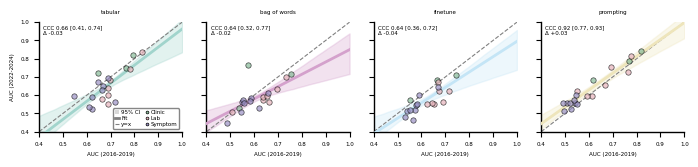

In [4]:
fig, axes = plot_split_concordance(tidy_df_restrict, point_estimate_df_restrict, color_map, x_split='test', y_split='inference', figsize_mm=(180,45))

In [ ]:
fig.savefig("performance_across_shifts_epr_vs_epic.svg")

In [6]:
tidy_df_restrict = tidy_df.loc[tidy_df['split'].isin(['inference_aero', 'inference_other'])].copy()
point_estimate_df_restrict = point_estimate_df.loc[point_estimate_df['split'].isin(['inference_aero', 'inference_other'])].copy()

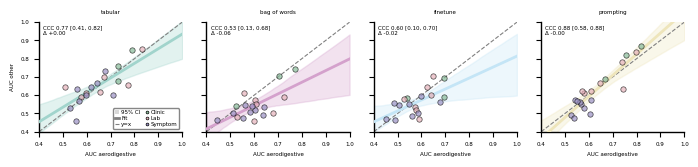

In [7]:
fig, axes = plot_split_concordance(tidy_df_restrict, point_estimate_df_restrict, color_map, x_split='inference_aero', y_split='inference_other', figsize_mm=(180,45))

In [ ]:
fig.savefig("performance_across_shifts_aero_vs_other.svg")

In [9]:
# load results from delong test
df_delong_epr_v_epic = pd.read_csv('/Users/wayne/Desktop/Cluster/WorkDirHome/gitrepo/2024/OncoTRAIL/paper/pmh_method/results/aggregate/delong_comparison_test_vs_inference.csv')
df_delong_epr_v_epic = df_delong_epr_v_epic.loc[df_delong_epr_v_epic['method'] != 'nlp-count']
df_delong_aero_vs_other = pd.read_csv('/Users/wayne/Desktop/Cluster/WorkDirHome/gitrepo/2024/OncoTRAIL/paper/pmh_method/results/aggregate/delong_comparison_aero_vs_nonaero.csv')
df_delong_aero_vs_other = df_delong_aero_vs_other.loc[df_delong_aero_vs_other['method'] != 'nlp-count']

In [10]:
n_comparisons = len(df_delong_epr_v_epic) + len(df_delong_aero_vs_other)
alpha = 0.05 / n_comparisons

In [11]:
epr_v_epic_stat_significant = df_delong_epr_v_epic.loc[df_delong_epr_v_epic['p_value'] < alpha]
# loop over the methods and print the targets for each method
for method in epr_v_epic_stat_significant['method'].unique():
    print(f"Method: {method}")
    targets = epr_v_epic_stat_significant.loc[epr_v_epic_stat_significant['method'] == method]['target'].unique()
    print(f"Targets: {targets}")
    print()

Method: tabular
Targets: ['target_esas_pain_3pt_change' 'target_neutrophil_grade2plus']



In [12]:
aero_v_other_stat_significant = df_delong_aero_vs_other.loc[df_delong_aero_vs_other['p_value'] < alpha]
# loop over the methods and print the targets for each method
for method in aero_v_other_stat_significant['method'].unique():
    print(f"Method: {method}")
    targets = aero_v_other_stat_significant.loc[aero_v_other_stat_significant['method'] == method]['target'].unique()
    print(f"Targets: {targets}")
    print()